In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
load_path = f'./weights/layer-7-{task_name}.pt'
history = torch.load(load_path, map_location='cpu')

In [26]:
history.keys()

dict_keys(['model_state_dict', 'layer_track', 'train_stats', 'metrics_after_merge', 'metrics_after_recovery', 'merge_iteration', 'num_layers', 'is_retrained'])

In [27]:
history['layer_track']

[[0], [1, 2], [3], [4], [5], [6, 7], [8, 9, 10, 11]]

In [28]:
from merge_helper import merge_bert_layers

In [29]:
for merge_layer, layer in enumerate(history['layer_track']):
    if len(layer) > 1:
        print("Merged Layer:", merge_layer)
        for _ in range(len(layer) -  1):
            merged = merge_bert_layers(model, merge_layer, merge_layer + 1)
            model.bert.encoder.layer[merge_layer] = merged
            del model.bert.encoder.layer[merge_layer + 1]

Merged Layer: 1
Merged Layer: 5
Merged Layer: 6


In [30]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda')

In [31]:
from train_eval_func import eval_loop

In [32]:
eval_loop(model, eval_dataloader, task_name, device)

({'accuracy': 0.33507246376811595, 'f1': 0.0}, 1.0795933449709858)

In [34]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [36]:
for batch in train_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
    break

In [37]:
outputs.keys()

odict_keys(['loss', 'logits', 'hidden_states', 'attentions'])

In [44]:
outputs['hidden_states']['hidden_states'][0].shape

torch.Size([32, 75, 768])

In [45]:
outputs['hidden_states']['hidden_states'][6].shape

torch.Size([32, 75, 768])

In [50]:
outputs['attentions']['attention_head'][0].shape

torch.Size([32, 12, 75, 75])

In [51]:
outputs['attentions']['attention_head'][6].shape

torch.Size([32, 48, 75, 75])

# 5. Learning Rate and Leanring Scheduler Setup

In [33]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=3e-5)

In [34]:
from train_eval_func import set_lr_scheduler

num_epochs = 10
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = set_lr_scheduler(
    optimizer          = optimizer,
    num_training_steps = num_training_steps
)

print(num_training_steps)

1150


In [35]:
patience=3
save_path=f'./weights/bert-{task_name}.pt'

# 6. Training

In [36]:
from train_eval_func import train

In [37]:
train_stats = train(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    num_epochs=num_epochs,
    lr=lr_scheduler,
    patience=patience,
    use_early_stopping=True,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    # save_path=save_path,
    display_epoch_iter=True
)

Training:   0%|          | 0/1150 [00:00<?, ?it/s]/home/abhinavl/work/Layer_Graft/layer-grafting-publication/similar_layer_merge/../train_eval_func.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|█         | 115/1150 [00:12<01:38, 10.46it/s]


<----------------- Epoch 1 ----------------->
Loss: 0.56, Training Metrics:
  accuracy: 0.7099
  f1: 0.8022
Validation Loss: 0.42, Validation Metrics:
  accuracy: 0.8260
  f1: 0.8711
Elapsed Time: 13.2561 sec


Training:  20%|█▉        | 229/1150 [00:25<01:29, 10.25it/s]


<----------------- Epoch 2 ----------------->
Loss: 0.35, Training Metrics:
  accuracy: 0.8411
  f1: 0.8818
Validation Loss: 0.36, Validation Metrics:
  accuracy: 0.8284
  f1: 0.8649
Elapsed Time: 13.1364 sec


Training:  30%|███       | 345/1150 [00:38<01:20, 10.05it/s]

...


<----------------- Epoch 8 ----------------->
Loss: 0.02, Training Metrics:
  accuracy: 0.9956
  f1: 0.9968
Validation Loss: 1.23, Validation Metrics:
  accuracy: 0.8480
  f1: 0.8953
Elapsed Time: 13.5469 sec


Training:  90%|████████▉ | 1034/1150 [01:59<00:13,  8.85it/s]


<----------------- Epoch 9 ----------------->
Loss: 0.01, Training Metrics:
  accuracy: 0.9973
  f1: 0.9980
Validation Loss: 1.32, Validation Metrics:
  accuracy: 0.8431
  f1: 0.8930
Elapsed Time: 13.4883 sec


Training: 100%|██████████| 1150/1150 [02:14<00:00,  8.57it/s]


<----------------- Epoch 10 ----------------->
Loss: 0.01, Training Metrics:
  accuracy: 0.9975
  f1: 0.9982
Validation Loss: 1.34, Validation Metrics:
  accuracy: 0.8480
  f1: 0.8956
Elapsed Time: 13.9436 sec

Total Training Time: 134.17 sec


### Plotting Loss

In [38]:
from train_eval_func import plotLoss, plotAccuracy

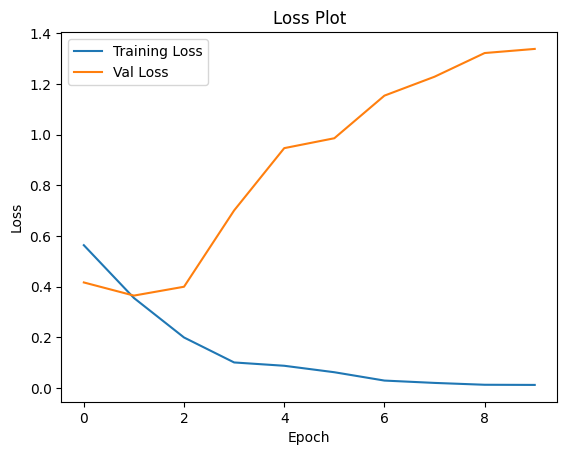

In [39]:
plotLoss(train_stats['train_losses'], train_stats['val_losses'], title="Loss Plot")

### Plotting Accuracy

In [40]:
def getMetricList(train_stats, metric_name='accuracy'):
    train_values = [m[metric_name] for m in train_stats['train_metrics_history']]
    val_values = [m[metric_name] for m in train_stats['val_metrics_history']]

    return train_values, val_values

In [41]:
train_values, val_values = getMetricList(train_stats)

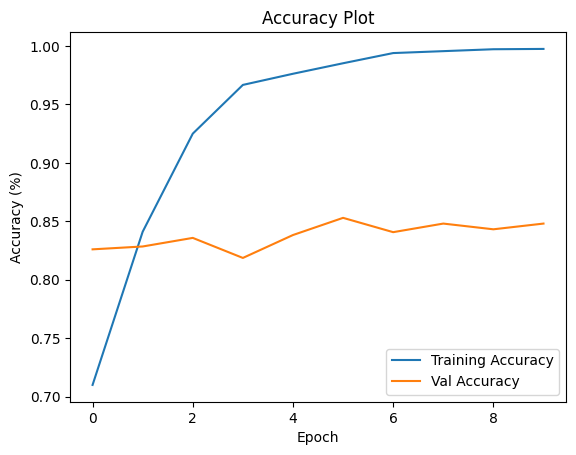

In [42]:
plotAccuracy(train_values, val_values, title="Accuracy Plot")

In [43]:
train_values, val_values = getMetricList(train_stats, 'f1')

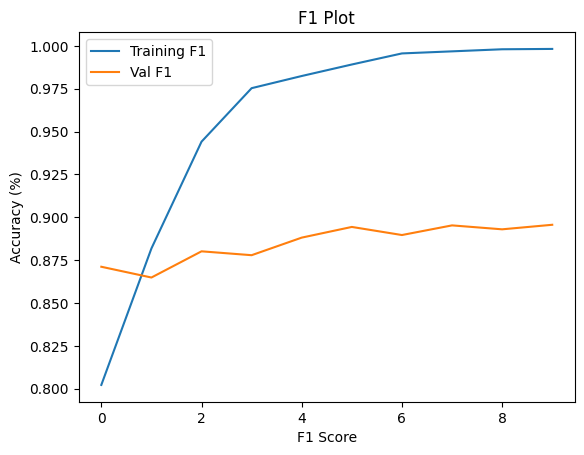

In [44]:
plotAccuracy(train_values, val_values, legend=["Training F1", "Val F1"], title="F1 Plot", xlabel="F1 Score")

# 7. Evaluation

In [45]:
best_weight = torch.load(save_path)

FileNotFoundError: [Errno 2] No such file or directory: './weights/bert-mrpc.pt'

In [46]:
model.load_state_dict(best_weight['model_state_dict'])

NameError: name 'best_weight' is not defined

In [47]:
eval_loop(model, eval_dataloader, task_name, device)[0]

{'accuracy': 0.8226086956521739, 'f1': 0.8735537190082645}

In [48]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8480392156862745, 'f1': 0.8956228956228957}

In [44]:
best_weight['epoch']

5